In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn import metrics
import xgboost as xgb
import time
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("data_with_predicted_refus_tamis.csv")
data

,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY,refus_tamis
0,10.185185,121.003326,576.604736,24.959060
1,10.185185,121.003326,576.604736,24.959060
2,10.185185,121.003326,576.604736,24.959060
3,10.185185,121.003326,576.604736,24.959060
4,10.185185,121.003326,576.604736,24.959060
...,...,...,...,...
101066,10.256077,106.631118,507.211636,17.686551
101067,10.256077,106.631118,511.160186,21.945082
101068,10.256077,106.631118,509.005283,20.736405
101069,10.256077,106.631118,510.360491,21.945082


<AxesSubplot:>

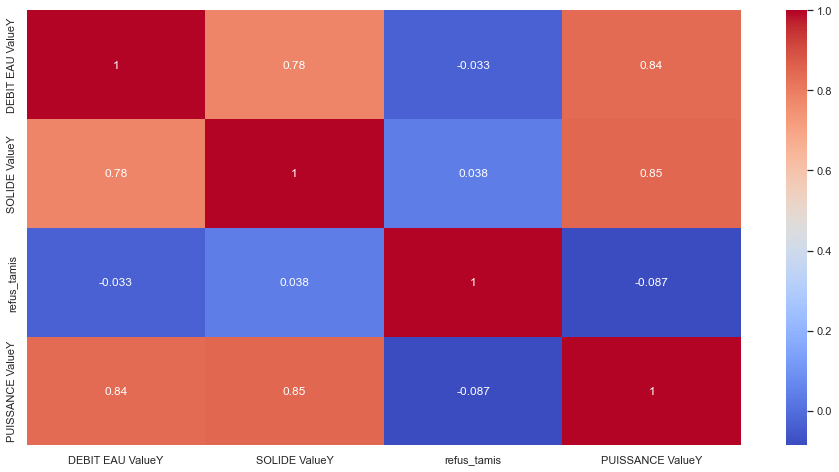

In [3]:
df = data[["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis","PUISSANCE ValueY"]]
sns.set(rc = {'figure.figsize':(16,8)})
sns.heatmap(df.corr(), annot = True, fmt='.2g',cmap= 'coolwarm')

Split dep_test with 100 observations

In [6]:
dep_test = data.sample(100)
dep_test

,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY,refus_tamis
65972,11.759003,110.774506,544.742235,26.082944
26736,11.555056,110.129006,596.481742,15.220238
47589,12.044504,112.748924,585.456086,15.714550
38402,12.184746,112.108674,592.632337,16.410283
59539,10.752221,116.658382,560.826973,22.263232
...,...,...,...,...
44049,11.494736,116.690176,570.878751,16.917381
79893,0.000000,0.000000,0.000000,22.290000
26041,14.113953,136.110587,605.125258,19.908309
88823,9.514892,114.429906,529.530772,20.102850


In [7]:
data.drop(dep_test.index, inplace=True)

In [8]:
data.shape

(100971, 4)

In [9]:
X = data[["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
X

,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
0,10.185185,121.003326,24.959060
1,10.185185,121.003326,24.959060
2,10.185185,121.003326,24.959060
3,10.185185,121.003326,24.959060
4,10.185185,121.003326,24.959060
...,...,...,...
101066,10.256077,106.631118,17.686551
101067,10.256077,106.631118,21.945082
101068,10.256077,106.631118,20.736405
101069,10.256077,106.631118,21.945082


In [10]:
y = data[["PUISSANCE ValueY"]]
y

,PUISSANCE ValueY
0,576.604736
1,576.604736
2,576.604736
3,576.604736
4,576.604736
...,...
101066,507.211636
101067,511.160186
101068,509.005283
101069,510.360491


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [12]:
X_train

,DEBIT EAU ValueY,SOLIDE ValueY,refus_tamis
16193,10.396832,112.896518,20.900654
69482,11.249137,136.453900,18.896273
86716,9.437304,115.443513,20.780851
97483,10.864318,110.003134,26.079195
14204,10.273157,117.683657,18.780097
...,...,...,...
6269,9.022714,109.218268,20.099756
54942,10.841360,116.180020,21.667322
76895,8.593991,106.454958,20.786999
861,10.323471,119.338047,18.763516


In [13]:
y_train

,PUISSANCE ValueY
16193,557.250920
69482,537.959258
86716,520.986890
97483,515.365588
14204,570.156706
...,...
6269,540.554988
54942,544.736976
76895,527.844883
861,556.592670


In [14]:
(X_train.isna().sum()/X_train.shape[0]).sort_values(ascending=True)

DEBIT EAU ValueY    0.0
SOLIDE ValueY       0.0
refus_tamis         0.0
dtype: float64

In [15]:
(X_test.isna().sum()/X_test.shape[0]).sort_values(ascending=True)

DEBIT EAU ValueY    0.0
SOLIDE ValueY       0.0
refus_tamis         0.0
dtype: float64

In [16]:
dep_test_X = dep_test[["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis"]]
dep_test_Y = dep_test[["PUISSANCE ValueY"]]

In [17]:
(dep_test_X.isna().sum()/dep_test_X.shape[0]).sort_values(ascending=True)

DEBIT EAU ValueY    0.0
SOLIDE ValueY       0.0
refus_tamis         0.0
dtype: float64

KNN Regression
XGBoost

KNN Regression

In [18]:
Start_Time = time.time()
knn_model = KNeighborsRegressor(n_neighbors=5).fit(X_train, y_train)
Execution_Time_knn = time.time() - Start_Time
score_knn_train = knn_model.score(X_train, y_train)
score_knn_train

0.9816223146564712

In [19]:
score_knn_test = knn_model.score(X_test, y_test)
score_knn_test

0.9707050525865585

XGBoost

In [20]:
model = xgb.XGBRegressor()
Start_Time = time.time()
model.fit(X_train, y_train)
Execution_Time_xgboost = time.time() - Start_Time
print(model)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0, gpu_id=-1,
             grow_policy='depthwise', importance_type=None,
             interaction_constraints='', learning_rate=0.300000012, max_bin=256,
             max_cat_threshold=64, max_cat_to_onehot=4, max_delta_step=0,
             max_depth=6, max_leaves=0, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, ...)


In [21]:
model.score(X_train, y_train)

0.9987723012486188

In [22]:
model.score(X_test, y_test)

0.9969564941354524

Evaluation par RMSE de ces 4 algorithme

In [23]:
print("KNN Regression: ", np.sqrt(metrics.mean_squared_error(y_test,knn_model.predict(X_test))))
print("XGBoost Regression: ", np.sqrt(metrics.mean_squared_error(y_test,model.predict(X_test))))

KNN Regression:  25.039531274341286
XGBoost Regression:  8.070805940023188


prediction for the test sample

In [24]:
##############################################################
Start_time = time.time()
y_predict_dep_test_knn = knn_model.predict(X_test)
knn_pred_time = time.time() - Start_time
##############################################################
Start_time = time.time()
y_predict_dep_test_xgboost = model.predict(X_test)
xgboost_pred_time = time.time() - Start_time

Compare the performance of models

In [25]:
pd.DataFrame({'MSE':[metrics.mean_squared_error(y_test,knn_model.predict(X_test)),metrics.mean_squared_error(y_test,model.predict(X_test))],
              'MAE': [metrics.mean_absolute_error(y_test,knn_model.predict(X_test)),metrics.mean_absolute_error(y_test,model.predict(X_test))],
              'R2':[knn_model.score(X_test, y_test),model.score(X_test, y_test)],
              'Time of Execution train (s)':[Execution_Time_knn,Execution_Time_xgboost],
              'Time of prediction test (s)':[knn_pred_time,xgboost_pred_time]}, index=["KNN","XGBoost"])

,MSE,MAE,R2,Time of Execution train (s),Time of prediction test (s)
KNN,626.978126,10.292225,0.970705,0.078905,0.190948
XGBoost,65.137909,3.104349,0.996956,2.089864,0.013969


Evaluate the model with dep_test sample and plot the result

In [26]:
y_predict_dep_test_knn = knn_model.predict(dep_test_X)
y_predict_dep_test_xgboost = model.predict(dep_test_X)

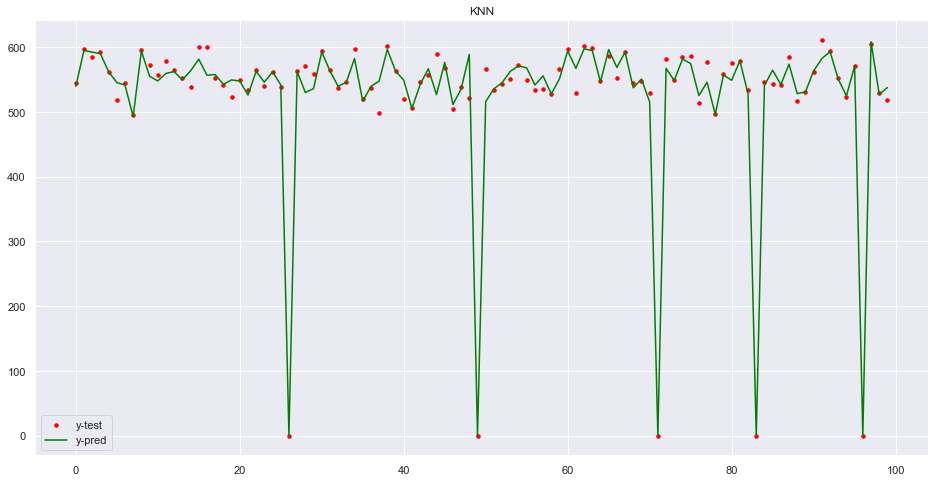

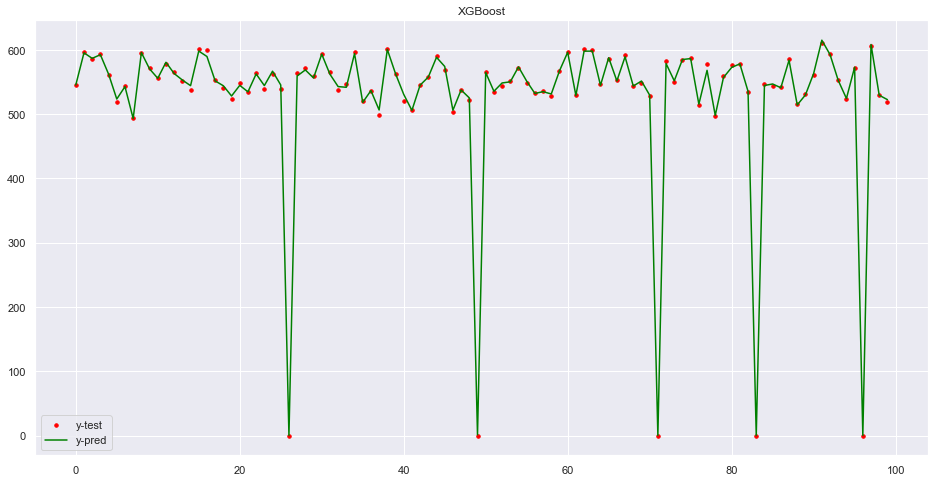

In [34]:
list_prediction = [y_predict_dep_test_knn,y_predict_dep_test_xgboost]
list_alg = ["KNN","XGBoost"]
for pred,alg in zip(list_prediction,list_alg):
    x_ax = range(len(dep_test_X))
    plt.scatter(x_ax, dep_test_Y,  s=12, label="y-test",c= "red")
    plt.plot(x_ax, pred, label="y-pred",c = "green")
    plt.legend()
    plt.title(alg)
    plt.show()

Comparaison Réelle & Prediction pour le deployement sample

In [35]:
prediction = pd.DataFrame(list(zip(dep_test_Y["PUISSANCE ValueY"],knn_model.predict(dep_test_X).T.tolist()[0],model.predict(dep_test_X).T.tolist())), columns = ['Puissance Réelle','Prediction KNN','Prediction XGBoost'])
prediction

,Puissance Réelle,Prediction KNN,Prediction XGBoost
0,544.742235,539.513400,545.156128
1,596.481742,594.977101,595.251221
2,585.456086,592.249242,586.595764
3,592.632337,590.012144,592.284973
4,560.826973,562.082173,562.088501
...,...,...,...
95,570.878751,570.533258,572.852356
96,0.000000,0.000000,0.083380
97,605.125258,608.237222,608.158203
98,529.530772,526.988512,529.250916


In [ ]:
prediction.to_excel("prediction_1_value_per_day_with_predicted_refus_tamis.xlsx", index=False)